In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd

from src.churn.preprocessing import *

In [2]:
df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "online_retail_processed.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,TotalPrice,Year,Month,Day,DayOfWeek,Hour,Quarter,IsWeekend,InvoiceMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,1,Tuesday,7,4,False,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,1,Tuesday,7,4,False,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,1,Tuesday,7,4,False,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,1,Tuesday,7,4,False,2009-12


In [3]:
customer_data = prepare_customer_data(df)

customer_data.head()

KeyError: 'CustomerID'

In [4]:
print(df.columns.tolist())


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'is_cancelled', 'TotalPrice', 'Year', 'Month', 'Day', 'DayOfWeek', 'Hour', 'Quarter', 'IsWeekend', 'InvoiceMonth']


In [5]:
from importlib import reload
import src.churn.preprocessing as preprocessing

reload(preprocessing)

from src.churn.preprocessing import *

In [6]:
customer_data = prepare_customer_data(df)

customer_data.head()


,Customer ID,Frequency,TotalQuantity,TotalSpent,AvgOrderValue,Recency,CustomerAge
0,12346.0,17,53,-51.74,-1.100851,325,400
1,12347.0,8,2967,4921.53,22.169054,1,402
2,12348.0,5,2714,2019.40,39.596078,74,362
3,12349.0,5,1619,4404.54,24.469667,18,716
4,12350.0,1,197,334.40,19.670588,309,0


In [7]:
customer_data["Churn"].value_counts()

KeyError: 'Churn'

In [8]:
print(customer_data.columns.tolist())

['Customer ID', 'Frequency', 'TotalQuantity', 'TotalSpent', 'AvgOrderValue', 'Recency', 'CustomerAge']


In [9]:
customer_data = create_churn_label(customer_data)

customer_data.head()

,Customer ID,Frequency,TotalQuantity,TotalSpent,AvgOrderValue,Recency,CustomerAge,Churn
0,12346.0,17,53,-51.74,-1.100851,325,400,1
1,12347.0,8,2967,4921.53,22.169054,1,402,0
2,12348.0,5,2714,2019.40,39.596078,74,362,0
3,12349.0,5,1619,4404.54,24.469667,18,716,0
4,12350.0,1,197,334.40,19.670588,309,0,1


In [10]:
print(customer_data.columns.tolist())

['Customer ID', 'Frequency', 'TotalQuantity', 'TotalSpent', 'AvgOrderValue', 'Recency', 'CustomerAge', 'Churn']


In [11]:
customer_data["Churn"].value_counts()

Churn
1    3020
0    2922
Name: count, dtype: int64

In [12]:
from importlib import reload

import src.churn.model as model_module
import src.churn.evaluation as evaluation_module
import src.churn.visualization as visualization_module

reload(model_module)
reload(evaluation_module)
reload(visualization_module)

from src.churn.model import *
from src.churn.evaluation import *
from src.churn.visualization import *

In [13]:
X_train, X_test, y_train, y_test = prepare_train_test(customer_data)

print(X_train.shape)
print(X_test.shape)

(4753, 6)
(1189, 6)


In [14]:
rf_model = train_random_forest(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [15]:
metrics, cm, report = evaluate_model(
    rf_model,
    X_test,
    y_test
)

print(metrics)

{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'ROC AUC': 1.0}


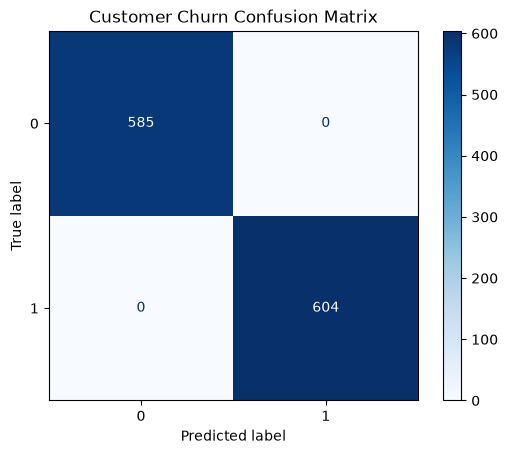

In [16]:
plot_confusion_matrix(
    rf_model,
    X_test,
    y_test
)

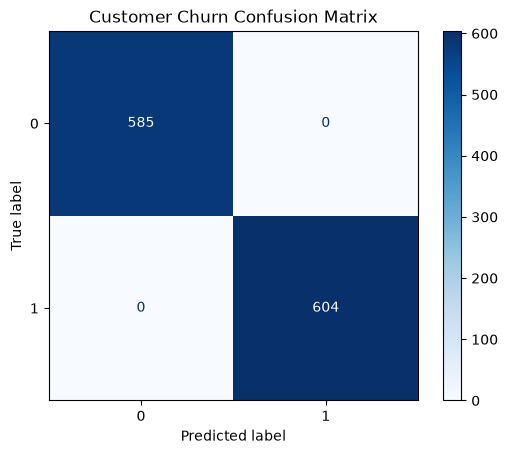

In [17]:
plot_confusion_matrix(
    rf_model,
    X_test,
    y_test
)

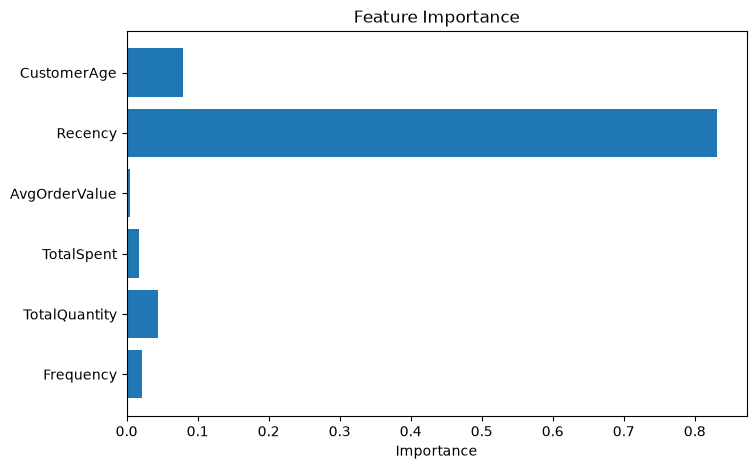

In [18]:
plot_feature_importance(
    rf_model,
    X_train.columns
)

In [19]:
import pandas as pd

predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_model.predict(X_test)
})

predictions.to_csv(
    PROJECT_ROOT / "data" / "processed" / "customer_churn_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [20]:
print(metrics)

{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'ROC AUC': 1.0}
